# Analyze "`Gene Ontology Analysis`" Results

## Purpose: 

{TODO}

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

import glob, pickle

import seaborn as sns

import matplotlib.pyplot as plt

In [2]:
parameter_combinations = [file.split("/")[-1].split(".")[0] for file in sorted(glob.glob("/home/jve4pt/RBFOX2-Mouse-Embryonic-Heart-Analysis/outputs/pickled_networks/differential_expression_tf_networks/*", recursive=True))]

parameter_combinations

['upstream_2500_score_900',
 'upstream_2500_score_950',
 'upstream_2500_score_990',
 'upstream_5000_score_900',
 'upstream_5000_score_950',
 'upstream_5000_score_990',
 'upstream_750_score_900',
 'upstream_750_score_950',
 'upstream_750_score_990']

In [3]:
go_results = {}

for parameter_combination in parameter_combinations:
    
    parameter_combination = parameter_combination.split("/")[-1].split(".")[0]
    
    go_results[parameter_combination] = {}
    
    for iteration in range(1000): 
        
        go_results[parameter_combination][iteration]  = {}
        
        tmp_files = glob.glob(
            "../../../../outputs/gene_ontology_analysis/differential_expression_networks/output/{}-iter_{}/*.tsv".format(parameter_combination, iteration)
        )
                
        if len(tmp_files)==0: 
            print("{} {}".format(parameter_combination, iteration))
            
        for file in tmp_files: 
                        
            go_results[parameter_combination][iteration][file.split("-")[-1].split(".")[0]] = pd.read_csv(file , sep="\t")



In [4]:
louvain_results = {}

for parameter_combination in parameter_combinations:
    
    parameter_combination = parameter_combination.split("/")[-1].split(".")[0]
    
    louvain_results[parameter_combination]={}
    
    for iteration in range(1000): 
        louvain_results[parameter_combination][iteration] = pickle.load(open("../../../../outputs/louvain_clustering/{}/{}-iter_{}.pkl".format(parameter_combination, parameter_combination, iteration), 'rb'))


In [5]:

plotter_df = pd.DataFrame(columns = ["Number of Clusters", "Parameter Combination"]) 

for parameter_combination in louvain_results:
    
    num_clusters = []
    
    for iteration in louvain_results[parameter_combination]: 
        
        num_clusters.append(len(louvain_results[parameter_combination][iteration]))
        
    tmp = pd.DataFrame()
    tmp["Number of Clusters"] = num_clusters 
    tmp["Parameter Combination"] = ["-".join(parameter_combination.split("_")[i] for i in [1,3])]*len(louvain_results[parameter_combination])
    
    plotter_df = pd.concat([plotter_df, tmp])

plotter_df.head()

,Number of Clusters,Parameter Combination
0,14,2500-900
1,13,2500-900
2,14,2500-900
3,11,2500-900
4,12,2500-900


<Figure size 900x600 with 0 Axes>

Text(0.5, 1.0, 'Number of Clusters Across Iterations')

<AxesSubplot:title={'center':'Number of Clusters Across Iterations'}, xlabel='Parameter Combination', ylabel='Number of Clusters'>

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, '2500-900'),
  Text(1, 0, '2500-950'),
  Text(2, 0, '2500-990'),
  Text(3, 0, '5000-900'),
  Text(4, 0, '5000-950'),
  Text(5, 0, '5000-990'),
  Text(6, 0, '750-900'),
  Text(7, 0, '750-950'),
  Text(8, 0, '750-990')])

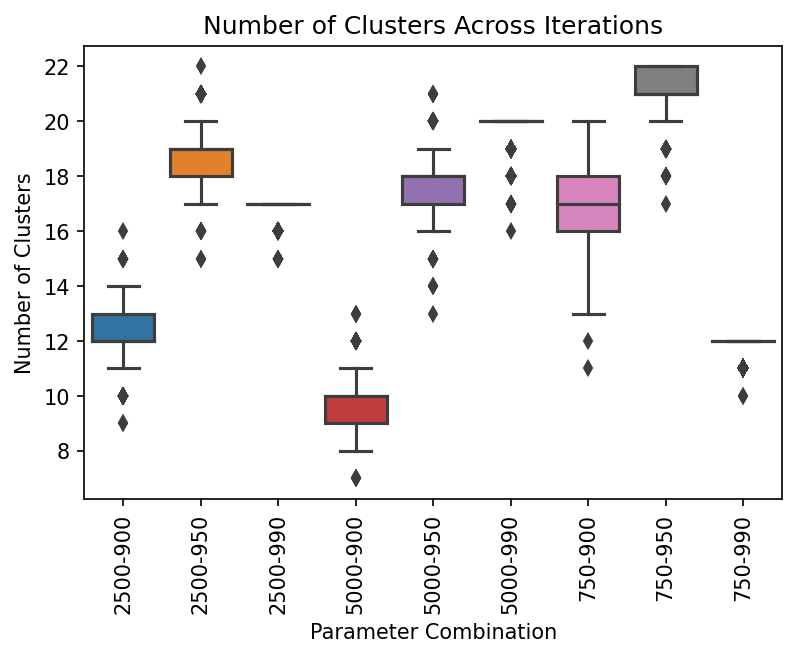

In [6]:
plt.figure(dpi = 150)

plt.title("Number of Clusters Across Iterations")

sns.boxplot(data=plotter_df, x="Parameter Combination", y="Number of Clusters")

plt.xticks(rotation=90)

In [7]:
relevant_go_terms = pd.DataFrame()

for parameter_combination in go_results: 
    parameter_combination
    for iteration in go_results[parameter_combination]: 
        for cluster in go_results[parameter_combination][iteration]: 
                        
            df = go_results[parameter_combination][iteration][cluster]
            
            df =df[(df["name"].str.contains("blood")) | (df["name"].str.contains("heart")) | (df["name"].str.contains("vascul")) | (df["name"].str.contains("circul")) | (df["name"].str.contains("cardiac"))]
            
            if df.index.size>0: 
                relevant_go_terms = pd.concat([relevant_go_terms, df])

'upstream_2500_score_900'

'upstream_2500_score_950'

'upstream_2500_score_990'

'upstream_5000_score_900'

'upstream_5000_score_950'

'upstream_5000_score_990'

'upstream_750_score_900'

'upstream_750_score_950'

'upstream_750_score_990'

In [8]:
relevant_go_terms[["# GO", "name"]].drop_duplicates()

,# GO,name
11,GO:1905072,cardiac jelly development
2,GO:0060045,positive regulation of cardiac muscle cell proliferation
3,GO:0048738,cardiac muscle tissue development
0,GO:0048514,blood vessel morphogenesis
11,GO:0035481,positive regulation of Notch signaling pathway involved in heart induction
0,GO:0014898,cardiac muscle hypertrophy in response to stress
15,GO:0060716,labyrinthine layer blood vessel development
0,GO:0086004,regulation of cardiac muscle cell contraction
0,GO:0007507,heart development
19,GO:0038033,positive regulation of endothelial cell chemotaxis by VEGF-activated vascular endothelial growth factor receptor signaling pathway


In [9]:
tmp = pd.DataFrame(relevant_go_terms["name"].value_counts())
tmp = tmp.reset_index()
tmp.columns=["Term", "Counts"]

tmp

,Term,Counts
0,blood vessel morphogenesis,1342
1,positive regulation of cardiac muscle cell proliferation,1197
2,positive regulation of Notch signaling pathway involved in heart induction,1145
3,cardiac muscle cell proliferation,995
4,positive regulation of endothelial cell chemotaxis by VEGF-activated vascular endothelial growth factor receptor signaling pathway,401
5,positive regulation of blood vessel endothelial cell migration,280
6,cardiac vascular smooth muscle cell differentiation,117
7,blood vessel development,112
8,cardiac vascular smooth muscle cell development,110
9,cardiac jelly development,108


## Within An Iteration, are the Relevant Terms Unique to a Cluster?

In [10]:
list_of_relevant_terms = relevant_go_terms["# GO"].unique().tolist()

unique_or_not = []
    
for parameter_combination in go_results: 

    for iteration in go_results[parameter_combination]: 
        
        iteration_df = pd.DataFrame()
        
        for cluster in go_results[parameter_combination][iteration]:

            tmp = go_results[parameter_combination][iteration][cluster]
            tmp = tmp[tmp["# GO"].isin(list_of_relevant_terms)]
            
            if tmp.index.size>1: 
                iteration_df = pd.concat([iteration_df,tmp])
            
        if iteration_df.index.size>1: 
            if iteration_df["# GO"].duplicated().any(): 
                unique_or_not.append(False)
            else: 
                unique_or_not.append(True)

                

In [11]:
pd.Series(unique_or_not).value_counts()

True     1597
False       1
dtype: int64